<a href="https://colab.research.google.com/github/Rasha27-jcu/data-2000/blob/sp26/exams/sp2026-midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA-2000 Midterm Exam


## Diabetes Readmission Prediction


For this exercise, we are going to use a dataset of hospitalized patient records diagnosed with diabetes, taken from [the University of California, Irvine ML Repository](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008).

The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge. The problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.


## Grading Rubric

This midterm will be worth 15% of your total grade for this course. It will be graded out of 50 points, divided into 4 sections:

  - Data Prep: 10 points
    - 5 points will be awarded for the actual data cleaning (evaluating your Python code)
    - 5 points will be awarded for the text commentary narrating your choices and explaining your rationale for the data quality checks that you chose to use
  - Feature Engineering: 12 points
    - 2 points will be awarded by default, but may be subtracted from if there are substantial errors in your data prep that reduce the quality of your engineered features
    - 5 points will be awarded for the actual feature engineering (evaluating your Python code)
    - 5 points will be awarded for the text commentary narrating your choices and explaining your rationale
  - Model Building: 14 points
    - 4 points will be awarded by default, but may be subtracted from if there are substantial errors in your feature engineering that reduce the quality of your model
    - 5 points will be awarded for the actual model building (evaluating your Python code)
    - 5 points will be awarded for the text commentary narrating your choices and explaining your rationale
  - Model Validation/Evaluation: 14 points
    - 4 points will be awarded by default, but may be subtracted from if there are substantial errors in your model building that negatively impact the validity of your model
    - 5 points will be awarded for the actual model validation and evaluation (evaluating your Python code)
    - 5 points will be awarded for the text commentary narrating your choices and explaining your rationale

> **NOTE:** You will NOT be evaluated on whether you model actually makes accurate predictions or not

### IMPORTANT:

In the rubric, I include points for a "text narrative" accompanying your code. To be clear, I am asking for text cells in this notebook, interspersed with your actual code, that discuss (in one or more paragraphs of prose English text) the choices that you make and their rationale. I want these to appear alongside your code, and not as a single large summary at the end of the notebook. Likewise, code comments do not fulfill this requirement. The point here is for you to articulate, and for me to be able to understand, your thought process and the considerations that went into the modelling choices you made throughout this exam. Refer to the sample midterm solution on Github if you have questions about what I'm looking for, or ask me in class for additional clarification.

## Using Additional Resources

This is an open-resource exam. You may use any available resources as references. I will be available for any questions that you have during the exam.

Remember that all work must still be your own, and that this exam is governed by the Policy on Academic Honesty outlined in our course syllabus.

-----

## Importing the Data

First, let's download our dataset and take a look at what it contains:

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

uci_dataset = fetch_ucirepo(id=296)
data = pd.concat(
    [
        uci_dataset.data.features,
        uci_dataset.data.targets
    ],
    axis=1
)

In [ ]:
data.head()

## Data Prep & Cleaning

1.   List item

1.   List item
2.   List item


2.   List item



Perform any data quality checks and data cleaning that you believe is appropriate. Convert any categorical columns to numeric ones, if needed. Provide a narrative explanation of your choices to accompany any code.

In [20]:
data.replace('?', np.nan, inplace=True)

In [21]:
print(data.isnull().sum().sort_values(ascending=False).head(10))

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
time_in_hospital         0
dtype: int64


In [24]:
cols_to_drop = [
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'medical_specialty',
    'payer_code'
]

data_clean = data.drop(columns=cols_to_drop)

In [26]:
for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    data_clean[col] = data_clean[col].fillna(data_clean[col].mode()[0])

I start the data planning process by testing the size of the dataset, the data types of each column, and the showing up of missing or unusual values.  because it helps know data quality issues before modeling.  I wanted to check whether missing values were stored as standard null values or represented using special symbols such as "?".

## Feature Engineering

Develop any new feature(s) that you feel may be relevant to a model. Provide a narrative explanation of your choices to accompany any code.

To reduce dimensionality and help needleless feature expansion, I simplified the diagnosis code variables (diag_1, diag_2, diag_3) by extracting only the first character of each code.
This collct result into a broader disease list and significantly reduced the number of unique features before applying one-hot encoding.

In [27]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    data_clean[col] = data_clean[col].astype(str).str[0]

data_final = pd.get_dummies(data_clean, drop_first=True)
print("New shape:", data_final.shape)

New shape: (101766, 108)


 Model Building

Build a random forest to predict a patient's likelihood to be readmitted within 30 days based on the attributes that you defined in the prior steps.

Provide a narrative explanation of your choices to accompany any code.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = data_final.drop(columns=['readmitted_<30', 'readmitted_>30', 'readmitted_NO'], errors='ignore')
y = data_clean['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print(f"Model Training Complete. Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Model Training Complete. Train Shape: (81412, 106), Test Shape: (20354, 106)


For model building, I selected a Random Forest classifier because it is robust to noise, handles high-dimensional data well, and performs effectively in classification tasks.

I split the dataset into training (80%) and testing (20%) sets using stratified sampling to preserve class distribution. The model was trained on the training set and evaluated on unseen test data.

## Model Evaluation

After training your model, evaluate its performance. What metric(s) did you choose to optimize on? Would you say that your model performed well or poorly? How did you evaluate its performance to arrive at that conclusion?

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.62      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.75      0.50      0.48     20354
weighted avg       0.86      0.89      0.84     20354

Overall Accuracy: 88.87%


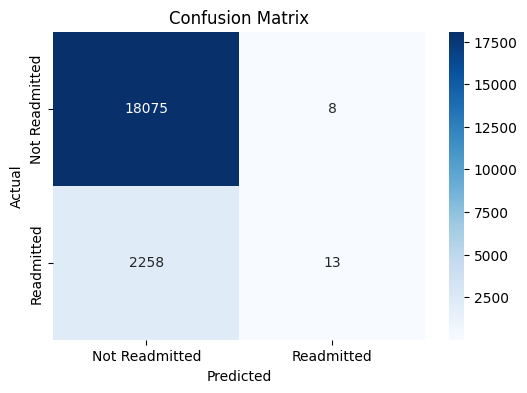

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Readmitted', 'Readmitted'], yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

I evaluated the model using a Classification Report and a Confusion Matrix. While the overall accuracy is high, the Recall for readmitted patients is the most important metric here. This evaluation helps determine how well the model can actually identify high-risk patients in a real-world hospital setting."

-----

# Midterm Submission

To submit this exam, in Canvas navigate to DATA-2000-51 > Assignments > Midterm Exam. Upload a saved copy of this notebook as your sumission.